# Data Size Impact Study
**Course**: CS 3402

This study investigates how the size of training data influences the performance of Classical ML models versus Artificial Neural Networks (ANNs).

### Data Download Instructions
Please download the following datasets from Kaggle and place the CSV files in the same directory as this notebook (or in a subfolder named `data/`).

1. **Credit Card Approval**: [Rikdifos Dataset](https://www.kaggle.com/datasets/rikdifos/credit-card-approval-prediction)
   * Need: `application_record.csv` and `credit_record.csv`.
2. **Student Placement**: [Sehaj Dataset](https://www.kaggle.com/datasets/sehaj1104/student-placement-prediction-dataset-2026)
   * Need: `student_placement_prediction_dataset_2026.csv`.
3. **Digital Distraction**: [Neurocipher Dataset](https://www.kaggle.com/datasets/neurocipher/digital-distraction-vs-academic-performance)
   * Need: CSV file (e.g., `student_digital_life.csv` or similar).

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, mean_absolute_error, r2_score, confusion_matrix
import os
import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading and Preprocessing

In [13]:
LIMIT_RECORDS = 5000

def find_path(filename):
    if os.path.exists(filename): return filename
    alt = os.path.join('data', filename)
    if os.path.exists(alt): return alt
    return None

def find_by_keywords(keywords):
    for folder in ['.', 'data']:
        if not os.path.exists(folder): continue
        for f in os.listdir(folder):
            if all(kw.lower() in f.lower() for kw in keywords) and f.endswith('.csv'):
                return os.path.join(folder, f)
    return None

def identify_target(df, keywords, default):
    """Finds a column name containing any of the keywords."""
    for col in df.columns:
        if any(kw.lower() in col.lower() for kw in keywords):
            return col
    return default

datasets = {}
print("Searching for datasets...")

# 1. Credit Card (Classification)
app_path = find_path('application_record.csv')
credit_path = find_path('credit_record.csv')
if app_path and credit_path:
    print("Found Credit Card dataset.")
    app_df = pd.read_csv(app_path, nrows=LIMIT_RECORDS)
    credit_df = pd.read_csv(credit_path)
    credit_df['target'] = credit_df['STATUS'].apply(lambda x: 1 if x in ['1', '2', '3', '4', '5'] else 0)
    target_agg = credit_df.groupby('ID')['target'].max().reset_index()
    datasets['Credit Card'] = {'df': pd.merge(app_df, target_agg, on='ID', how='inner'), 
                             'task': 'classification', 'target': 'target'}
else:
    print("MISSING: Credit Card dataset")

# 2. Student Placement (Classification)
student_file = find_by_keywords(['placement'])
if student_file:
    print(f"Found Student Placement dataset: {student_file}")
    df = pd.read_csv(student_file, nrows=LIMIT_RECORDS)

    target = 'placement_status'

    df[target] = df[target].astype(str).str.strip().str.lower().map({
        'not placed': 0,
        'placed': 1
    })

    # Drop useless columns
    df = df.drop(columns=['student_id'], errors='ignore')

    # Ordinal encoding
    if 'college_tier' in df.columns:
        df['college_tier'] = df['college_tier'].map({
            'Tier 1': 3,
            'Tier 2': 2,
            'Tier 3': 1
        })

    # Feature engineering
    if all(col in df.columns for col in ['cgpa', 'internships']):
        df['cgpa_x_internships'] = df['cgpa'] * df['internships']

    if all(col in df.columns for col in ['projects', 'certifications']):
        df['projects_x_certifications'] = df['projects'] * df['certifications']

    if all(col in df.columns for col in ['internships', 'projects']):
        df['experience_score'] = df['internships'] + df['projects']

    if all(col in df.columns for col in ['certifications', 'workshops']):
        df['skill_score'] = df['certifications'] + df['workshops']

    datasets['Student Placement'] = {
        'df': df,
        'task': 'classification',
        'target': target
    }

    print(f"  Using target column: {target}")
    print(df[target].value_counts())

else:
    print("MISSING: Student Placement dataset")
# 3. Digital Distraction (Regression)
dist_file = find_by_keywords(['digital'])
if dist_file:
    print(f"Found Digital Distraction dataset: {dist_file}")
    df = pd.read_csv(dist_file, nrows=LIMIT_RECORDS)
    target = identify_target(df, ['score', 'final', 'exam', 'performance'], 'final_exam_score')
    print(f"  Using target column: {target}")
    datasets['Digital Distraction'] = {'df': df, 'task': 'regression', 'target': target}
else:
    print("MISSING: Digital Distraction dataset")

Searching for datasets...
Found Credit Card dataset.
Found Student Placement dataset: .\student_placement_prediction_dataset_2026.csv
  Using target column: placement_status
placement_status
1    2730
0    2270
Name: count, dtype: int64
Found Digital Distraction dataset: .\student_digital_life.csv
  Using target column: final_exam_score


## 2. Exploratory Data Analysis (EDA)

In [14]:
for name, data in datasets.items():
    print(f"\n-- EDA for {name} --")
    display(data['df'].head(3))
    print(f"Loaded Samples: {len(data['df'])}")


-- EDA for Credit Card --


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,target
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0


Loaded Samples: 4478

-- EDA for Student Placement --


,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,24,Male,7.53,IT,2,4,6,1,99.238568,81.707722,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,0,0.00
1,21,Male,7.92,CSE,2,1,3,6,80.966123,63.116715,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,0,0.00
2,22,Female,8.60,EEE,3,0,1,1,49.177184,48.658753,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,1,11.99


Loaded Samples: 5000

-- EDA for Digital Distraction --


,student_id,age,gender,study_hours_per_day,smartphone_usage_hours,social_media_hours,gaming_hours,streaming_hours,sleep_hours,exercise_hours,class_attendance_percent,assignment_completion_percent,caffeine_intake_cups,mental_health_status,parent_education_level,internet_quality,motivation_level,final_exam_score
0,1,21,Female,3.01,0.26,1.77,0.26,1.71,5.32,0.70,64.87,74.11,2,Good,Masters,Average,6.32,82.70
1,2,23,Female,5.84,8.02,3.30,0.96,0.00,5.99,1.99,85.38,80.68,3,Average,Masters,Poor,2.52,85.65
2,3,20,Female,7.80,10.13,0.00,2.23,2.54,6.36,1.82,76.15,79.69,2,Good,HighSchool,Poor,3.98,88.14


Loaded Samples: 5000


## 3. Pipeline Setup

In [16]:
def create_pipeline(X, model):
    num_cols = X.select_dtypes(include=['int64', 'float64']).columns
    cat_cols = X.select_dtypes(exclude=['int64', 'float64']).columns
    
    preprocessor = ColumnTransformer(transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])
    return Pipeline([('pre', preprocessor), ('m', model)])

## 4. Experiment Loop

In [23]:
results = []
fractions = [0.1, 0.3, 0.5, 1.0]
seeds = [42, 123, 999]

from sklearn.metrics import (
    accuracy_score, f1_score,
    mean_squared_error, mean_absolute_error, r2_score,
    confusion_matrix
)
from sklearn.preprocessing import StandardScaler

for name, info in datasets.items():
    print(f"\nRunning Experiment: {name}...")

    df = info['df'].copy().dropna()
    target = info['target']

    if target not in df.columns:
        print(f"  ERROR: Target '{target}' not found in {name}. Available columns: {list(df.columns)}")
        continue

    # --- Split features / target ---
    X = df.drop(columns=[target, 'salary_package_lpa'], errors='ignore').copy()
    y = df[target].copy()

    # --- Target handling ---
    if info['task'] == 'classification':
        if y.dtype == 'object':
            y = y.astype(str).str.strip().str.lower().map({
                'not placed': 0,
                'placed': 1
            })

        if y.isna().any():
            raise ValueError(f"Target encoding failed for {name}. Values: {df[target].unique()}")

        y = y.astype(int)

        print(f"  Class distribution:\n{y.value_counts(normalize=True)}")

    else:
        y = pd.to_numeric(y, errors='coerce')

    # --- Encode categorical features ---
    X = pd.get_dummies(X)

    # --- Train / test split ---
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y if info['task'] == 'classification' else None
    )

    # --- Models ---
    if info['task'] == 'classification':
        models = {
            'Logistic Regression': LogisticRegression(max_iter=500),
            'MLP (ANN)': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300)
        }
    else:
        models = {
            'Ridge': Ridge(),
            'MLP (ANN)': MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=300)
        }

    for m_name, model in models.items():
        print(f"  Training {m_name}...")

        for frac in fractions:
            scores = []
            f1_scores = []
            mae_scores = []
            r2_scores = []
            cm = None

            for seed in seeds:

                # --- Subsample ---
                if frac < 1.0:
                    X_sub, _, y_sub, _ = train_test_split(
                        X_train_full,
                        y_train_full,
                        train_size=frac,
                        random_state=seed,
                        stratify=y_train_full if info['task'] == 'classification' else None
                    )
                else:
                    X_sub, y_sub = X_train_full, y_train_full

                # --- Scaling for MLP ---
                if 'MLP' in m_name:
                    scaler = StandardScaler()
                    X_sub_scaled = scaler.fit_transform(X_sub)
                    X_test_scaled = scaler.transform(X_test)

                    X_train_use = X_sub_scaled
                    X_test_use = X_test_scaled
                else:
                    X_train_use = X_sub
                    X_test_use = X_test

                # --- Train / predict ---
                try:
                    model.fit(X_train_use, y_sub)
                    preds = model.predict(X_test_use)
                except Exception as e:
                    print(f"    Skipping due to error: {e}")
                    continue

                # --- Metrics (FIXED) ---
                if info['task'] == 'classification':
                    acc = accuracy_score(y_test, preds)
                    f1 = f1_score(y_test, preds)

                    scores.append(acc)
                    f1_scores.append(f1)

                    if seed == seeds[-1]:
                        cm = confusion_matrix(y_test, preds)

                else:
                    rmse = np.sqrt(mean_squared_error(y_test, preds))
                    mae = mean_absolute_error(y_test, preds)
                    r2 = r2_score(y_test, preds)

                    scores.append(rmse)
                    mae_scores.append(mae)
                    r2_scores.append(r2)

            # --- Store results ---
            if len(scores) > 0:
                results.append({
                    'Dataset': name,
                    'Model': m_name,
                    'Fraction': frac,
                    'Samples': len(X_sub),
                    'Mean': np.mean(scores),
                    'Std': np.std(scores),
                    'F1 Mean': np.mean(f1_scores) if info['task'] == 'classification' else None,
                    'MAE Mean': np.mean(mae_scores) if info['task'] == 'regression' else None,
                    'R2 Mean': np.mean(r2_scores) if info['task'] == 'regression' else None,
                    'Confusion Matrix': cm if info['task'] == 'classification' else None,
                    'Task': info['task']
                })

results_df = pd.DataFrame(results)


Running Experiment: Credit Card...
  Class distribution:
target
0    0.889176
1    0.110824
Name: proportion, dtype: float64
  Training Logistic Regression...
  Training MLP (ANN)...

Running Experiment: Student Placement...
  Class distribution:
placement_status
1    0.546
0    0.454
Name: proportion, dtype: float64
  Training Logistic Regression...
  Training MLP (ANN)...

Running Experiment: Digital Distraction...
  Training Ridge...
  Training MLP (ANN)...


## 5. Visualization

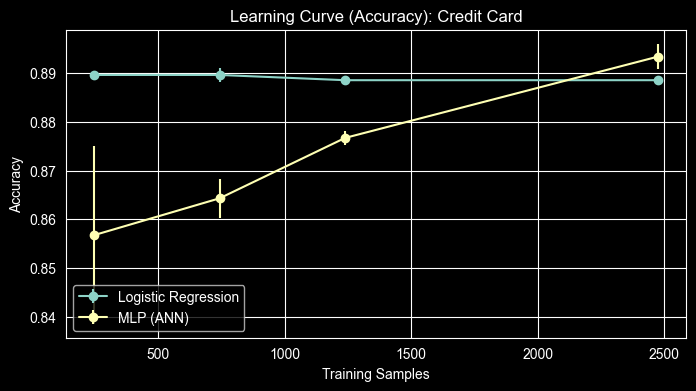

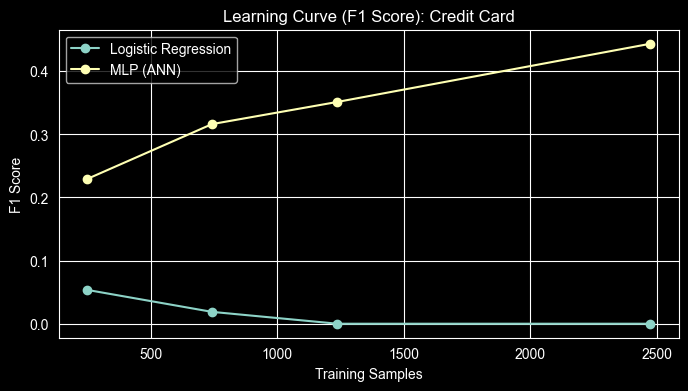

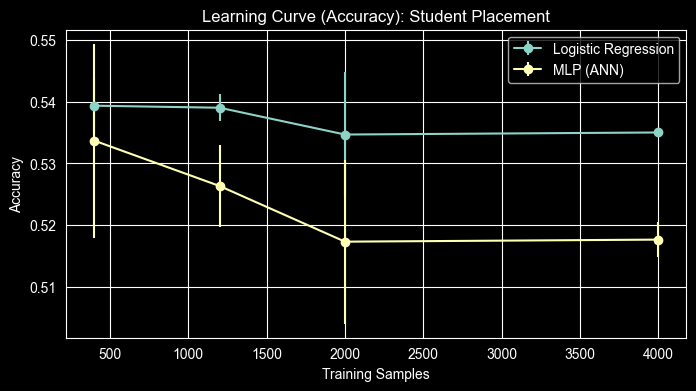

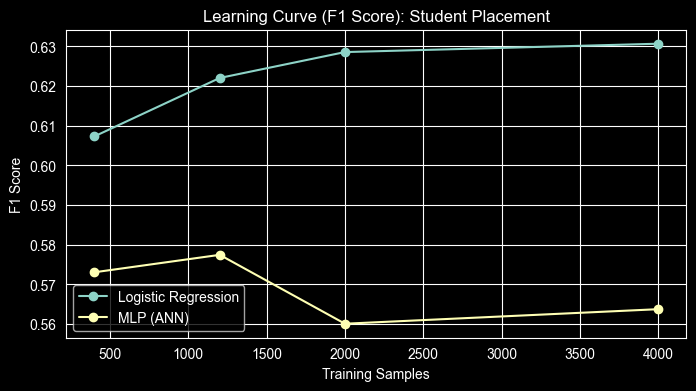

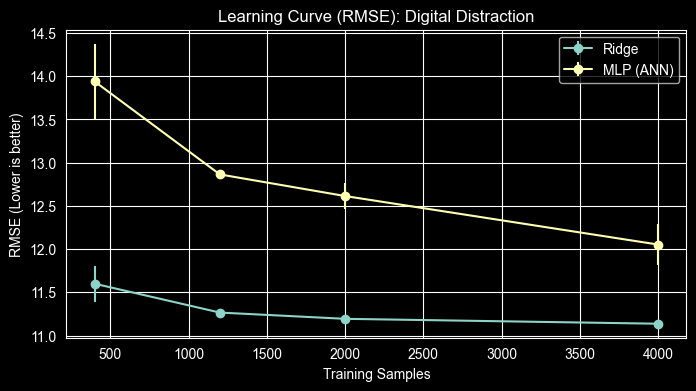

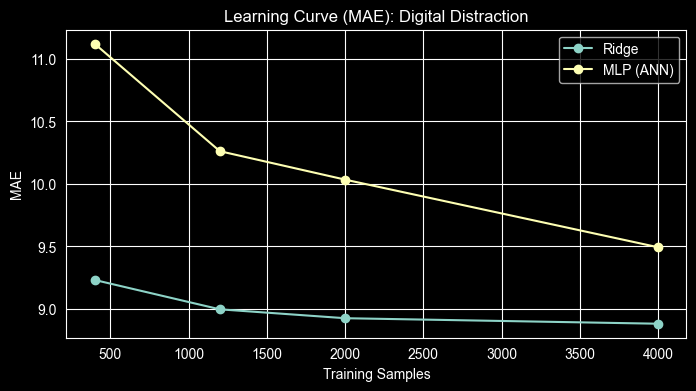

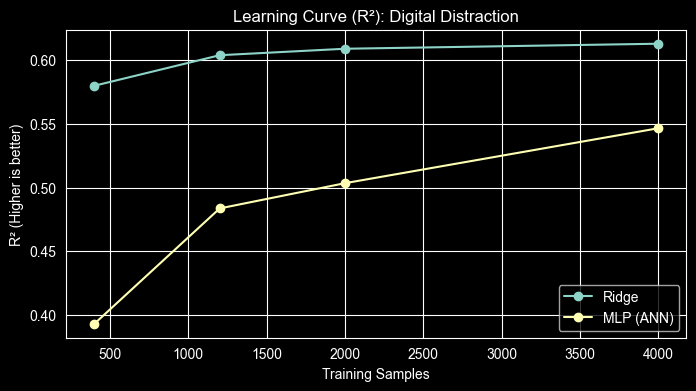

In [24]:
if not results_df.empty:
    for name in results_df['Dataset'].unique():
        sub = results_df[results_df['Dataset'] == name]
        task = sub['Task'].iloc[0]

        if task == 'classification':
            # Accuracy
            plt.figure(figsize=(8, 4))
            for m in sub['Model'].unique():
                m_sub = sub[sub['Model'] == m]
                plt.errorbar(m_sub['Samples'], m_sub['Mean'], yerr=m_sub['Std'], label=m, marker='o')
            plt.title(f"Learning Curve (Accuracy): {name}")
            plt.xlabel("Training Samples")
            plt.ylabel("Accuracy")
            plt.legend(); plt.grid(True); plt.show()

            # F1
            plt.figure(figsize=(8, 4))
            for m in sub['Model'].unique():
                m_sub = sub[sub['Model'] == m]
                plt.plot(m_sub['Samples'], m_sub['F1 Mean'], label=m, marker='o')
            plt.title(f"Learning Curve (F1 Score): {name}")
            plt.xlabel("Training Samples")
            plt.ylabel("F1 Score")
            plt.legend(); plt.grid(True); plt.show()

        else:
            # RMSE
            plt.figure(figsize=(8, 4))
            for m in sub['Model'].unique():
                m_sub = sub[sub['Model'] == m]
                plt.errorbar(m_sub['Samples'], m_sub['Mean'], yerr=m_sub['Std'], label=m, marker='o')
            plt.title(f"Learning Curve (RMSE): {name}")
            plt.xlabel("Training Samples")
            plt.ylabel("RMSE (Lower is better)")
            plt.legend(); plt.grid(True); plt.show()

            # MAE
            plt.figure(figsize=(8, 4))
            for m in sub['Model'].unique():
                m_sub = sub[sub['Model'] == m]
                plt.plot(m_sub['Samples'], m_sub['MAE Mean'], label=m, marker='o')
            plt.title(f"Learning Curve (MAE): {name}")
            plt.xlabel("Training Samples")
            plt.ylabel("MAE")
            plt.legend(); plt.grid(True); plt.show()

            # R²
            plt.figure(figsize=(8, 4))
            for m in sub['Model'].unique():
                m_sub = sub[sub['Model'] == m]
                plt.plot(m_sub['Samples'], m_sub['R2 Mean'], label=m, marker='o')
            plt.title(f"Learning Curve (R²): {name}")
            plt.xlabel("Training Samples")
            plt.ylabel("R² (Higher is better)")
            plt.legend(); plt.grid(True); plt.show()